# Análisis Exploratorio de Datos (EDA) - Detección de Fraude en Seguros de Auto

Este dataset contiene (1000 registros) información sobre pólizas de seguro, perfiles de clientes, características de vehículos y detalles de siniestros automovilísticos. El objetivo principal es identificar patrones que diferencien los reclamos legítimos de los fraudulentos (`fraud_reported`).



In [ ]:
# Cargamos librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## 1. Clasificación y Explicación de las Columnas

Con el primer vistazo, identificamos que en total tenemos 1000 registros de los cuales se obtienen 40 variables, las cuales definiremos aqui para comprender su relevancia analítica.

### A. Perfil del asegurado
* **`months_as_customer` (Meses como cliente) y `age` (Edad):** Permiten analizar la lealtad y el perfil demográfico. Ayudan a entender si los clientes más jóvenes o más nuevos presentan comportamientos de reclamo diferentes.
* **`insured_sex`, `insured_education_level`, `insured_occupation`, `insured_relationship`:** Variables demográficas estándar para segmentación. Permiten evaluar si el perfil socioeconómico influye en la siniestralidad.
* **`insured_hobbies` (Pasatiempos):** Variable conductual. Ciertos pasatiempos pueden estar correlacionados con perfiles de riesgo más altos o patrones inusuales en siniestros.
* **`capital-gains` (Ganancias de capital) y `capital-loss` (Pérdidas de capital):** 

### B. Detalles de la Póliza
* **`policy_number` e `insured_zip`:** Identificadores únicos
* **`policy_bind_date` (Fecha de emisión de póliza):** Crucial para calcular la antigüedad de la póliza al momento del accidente. (Reclamos muy cercanos a la fecha de contratación podrian ser alerta de fraude.)
* **`policy_state` (Estado de la póliza):** Distribución geográfica de la cartera.
* **`policy_csl` (Límites de responsabilidad combinados):** Define la cobertura máxima de la póliza por categoria **(Revisar si los montos vienen en millones/miles)**.
* **`policy_deductable` (Deducible):** Monto que el cliente paga de su bolsillo. 
* **`policy_annual_premium` (Prima anual):** Costo de la póliza. 
* **`umbrella_limit` (Límite de póliza):** Cobertura de responsabilidad civil adicional.

### C. Detalles del Incidente / Siniestro
* **`incident_date` (Fecha del incidente):** Permite evaluar factores de estacionalidad temporal (mes, día de la semana).
* **`incident_type` (Tipo de incidente) y `collision_type` (Tipo de colisión):** Clasifican la naturaleza del siniestro **(Tipo de colision tiene registros '?', verificar a qué se debe)**.
* **`incident_severity` (Gravedad del incidente):** Los daños calificados como menores o mayores deben guardar relación directa con los costos del reclamo.
* **`incident_hour_of_the_day` (Hora del día):** La severidad se podria ver asociada con la hora del día en que ocurrio el siniestro.
* **`incident_state`, `incident_city`, `incident_location`:** Ubicación geográfica del evento para detectar zonas de alta siniestralidad o fraude concentrado.
* **`authorities_contacted` (Autoridades contactadas) y `police_report_available` (Reporte policial disponible):** La ausencia de intervención policial en incidentes severos representa una anomalía grave.
* **`number_of_vehicles_involved` (Vehículos involucrados) y `witnesses` (Testigos):** Ayudan a corroborar la consistencia física del relato del accidente.
* **`property_damage` (Daño a propiedad) y `bodily_injuries` (Lesiones corporales):** Indicadores de la magnitud de los daños colaterales.

### D. Costos del Reclamo (Variables Financieras)
* **`total_claim_amount` (Monto total del reclamo):** La variable económica principal, se segrega en las siguientes variables:
  * `injury_claim` (Reclamo por lesiones).
    * `property_claim` (Reclamo por daños a la propiedad).
      * `vehicle_claim` (Reclamo por daños al vehículo asegurado).

      ### E. Datos del Vehículo
      * **`auto_make` (Marca), `auto_model` (Modelo), `auto_year` (Año):** Determinan el valor comercial y el costo de refacciones.

      ### F. Variable Objetivo y Columnas a Descartar
      * **`fraud_reported` (Fraude reportado):** La variable objetivo. Todo el EDA girará en torno a cómo el resto de las variables interactúan con esta.
      * **`_c39`:** Columna residual sin información útil generada comúnmente por errores de delimitación en la carga del archivo. **Debe ser eliminada.**



In [3]:
# Cargamos la base de datos
df = pd.read_csv('insurance_claims.csv')

In [6]:
# observamos la dimensión de la base de datos
df.shape

(1000, 40)

In [4]:
# Obtenemos un primer vistazo a la base de datos}
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,17/10/2014,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,27/06/2006,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,06/09/2000,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,25/05/1990,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,06/06/2014,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [5]:
# Obtenemos el tipo de dato de cada variable
df.dtypes

months_as_customer               int64
age                              int64
policy_number                    int64
policy_bind_date                object
policy_state                    object
policy_csl                      object
policy_deductable                int64
policy_annual_premium          float64
umbrella_limit                   int64
insured_zip                      int64
insured_sex                     object
insured_education_level         object
insured_occupation              object
insured_hobbies                 object
insured_relationship            object
capital-gains                    int64
capital-loss                     int64
incident_date                   object
incident_type                   object
collision_type                  object
incident_severity               object
authorities_contacted           object
incident_state                  object
incident_city                   object
incident_location               object
incident_hour_of_the_day 

## 2. Estrategia de Análisis en Pares (Análisis Bivariado)

Para encontrar los primeros *insights* significativos, enfocaremos el análisis bivariado en tres bloques clave:

### Bloque 1: Relación Directa con el Fraude (`fraud_reported` vs X)
* **`fraud_reported` vs `incident_severity`:** ¿El fraude se concentra en incidentes menores (fáciles de simular) o en pérdidas totales (para cobrar montos máximos)?
* **`fraud_reported` vs `police_report_available`:** Determinar si los reclamos sin reporte policial tienen una tasa de fraude significativamente más alta.
* **`fraud_reported` vs `capital-loss` / `capital-gains`:** Analizar si los problemas financieros del asegurado se vinculan con la declaración de fraudes.
* **`fraud_reported` vs `insured_hobbies`:** Evaluar si ciertos comportamientos o estilos de vida presentan anomalías estadísticas recurrentes.

### Bloque 2: Consistencia del Siniestro y Detección de Anomalías
* **`incident_severity` vs `total_claim_amount`:** Regla de negocio básica. Los incidentes leves no deben presentar reclamos económicos desproporcionadamente altos.
* **`number_of_vehicles_involved` vs `collision_type`:** Validación cruzada. Por ejemplo, si el tipo de colisión es contra un objeto fijo (*Single Vehicle Collision*), el número de vehículos involucrados obligatoriamente debe ser 1.
* **`incident_hour_of_the_day` vs `incident_severity`:** Evaluar si la hora en que ocurre el accidente influye directamente en su gravedad.

### Bloque 3: Análisis de Ciclo de Vida y Perfil de Activos
* **`age` vs `months_as_customer`:** Identificar la correlación natural del ciclo de vida del cliente. Permite detectar valores atípicos (ej. clientes de muy corta edad con demasiados meses de antigüedad).
* **`auto_year` vs `vehicle_claim`:** Verificar si los montos reclamados por daños al vehículo respetan la depreciación lógica asociada al año del auto.

In [8]:
pd.crosstab(df['incident_severity'],df['fraud_reported'],normalize='index'
)*100

fraud_reported,N,Y
incident_severity,,
Major Damage,39.492754,60.507246
Minor Damage,89.265537,10.734463
Total Loss,87.142857,12.857143
Trivial Damage,93.333333,6.666667


Generando Cuadrícula del Bloque 1...


C:\Users\derec\AppData\Local\Temp\ipykernel_25500\271752362.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='fraud_reported', y='capital-loss', palette='Set2', ax=axes[1, 0])
C:\Users\derec\AppData\Local\Temp\ipykernel_25500\271752362.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hobbies_fraud.values, y=hobbies_fraud.index, palette='magma', ax=axes[1, 1])


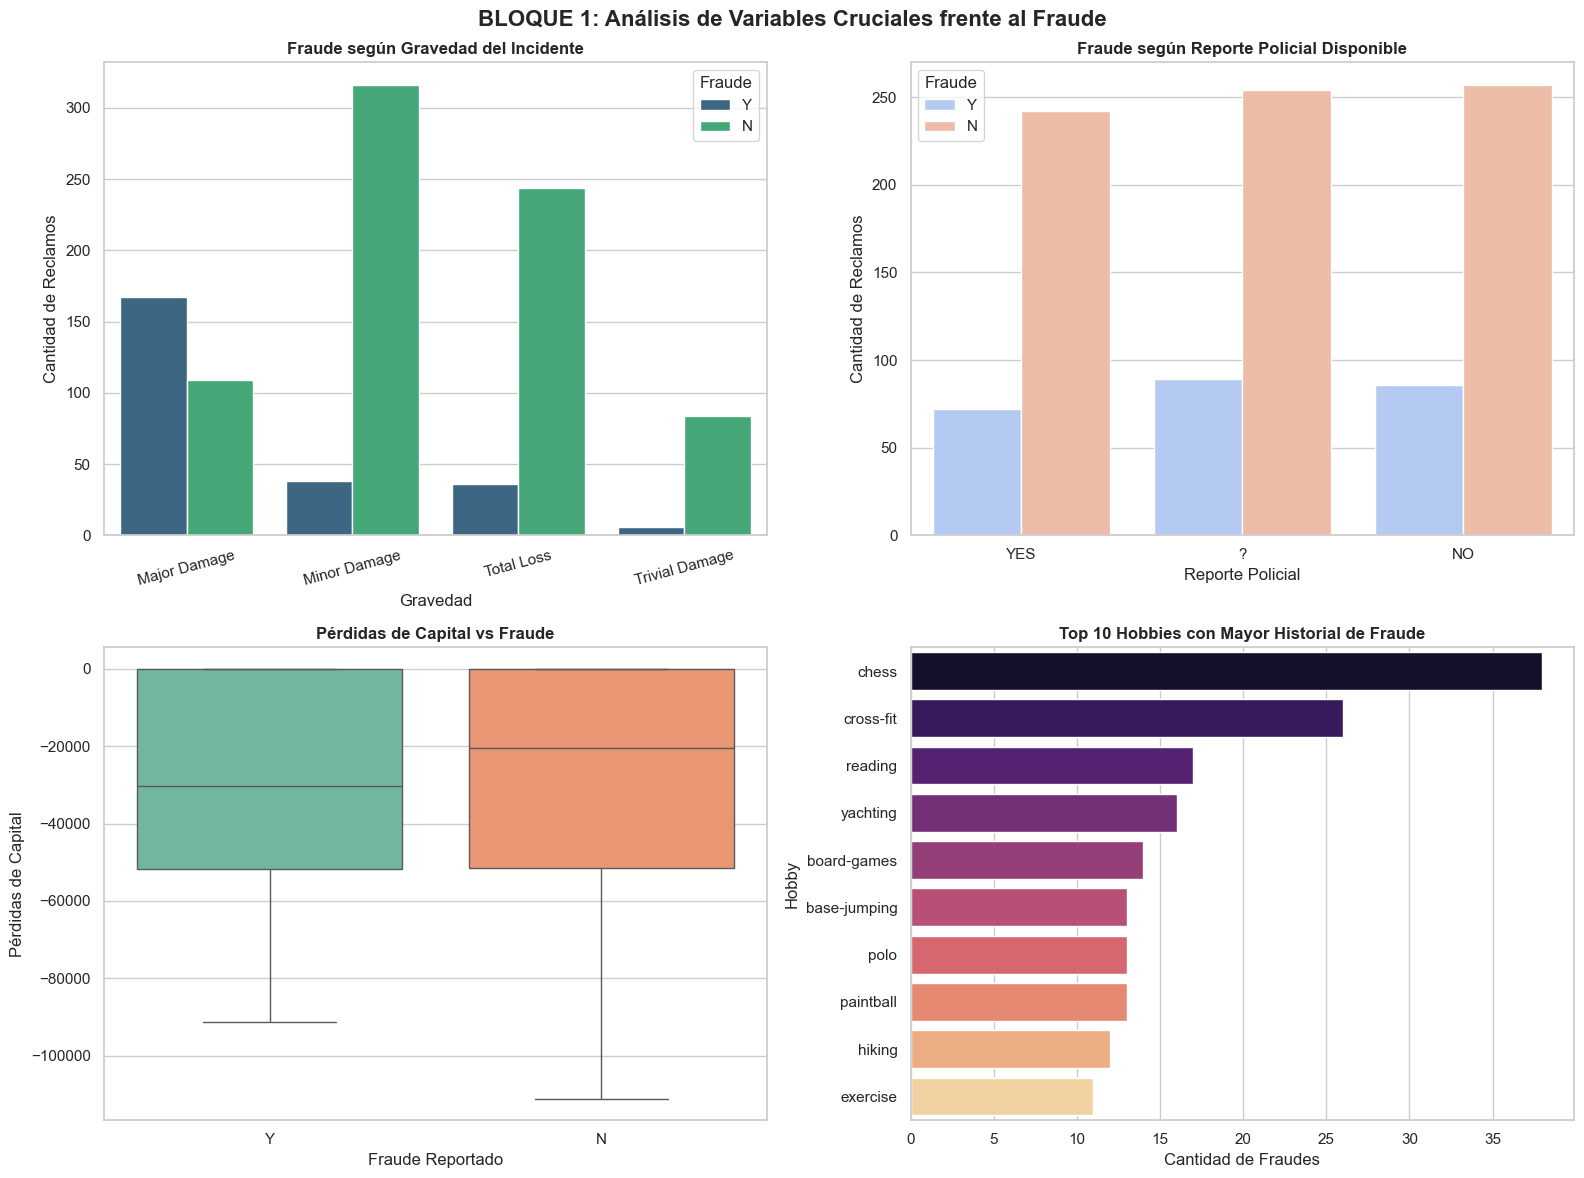

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configuración inicial de estilo
sns.set_theme(style="whitegrid")

# ==============================================================================
# BLOQUE 1: Relación Directa con el Fraude (Cuadrícula 2x2)
# ==============================================================================
print("Generando Cuadrícula del Bloque 1...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1.1. Gravedad del Incidente
sns.countplot(data=df, x='incident_severity', hue='fraud_reported', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Fraude según Gravedad del Incidente', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Gravedad')
axes[0, 0].set_ylabel('Cantidad de Reclamos')
axes[0, 0].legend(title='Fraude')
axes[0, 0].tick_params(axis='x', rotation=15)

# 1.2. Reporte Policial
sns.countplot(data=df, x='police_report_available', hue='fraud_reported', palette='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Fraude según Reporte Policial Disponible', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Reporte Policial')
axes[0, 1].set_ylabel('Cantidad de Reclamos')
axes[0, 1].legend(title='Fraude')

# 1.3. Pérdidas de Capital
sns.boxplot(data=df, x='fraud_reported', y='capital-loss', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Pérdidas de Capital vs Fraude', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Fraude Reportado')
axes[1, 0].set_ylabel('Pérdidas de Capital')

# 1.4. Top Hobbies con más Fraude
hobbies_fraud = df[df['fraud_reported'] == 'Y']['insured_hobbies'].value_counts().head(10)
sns.barplot(x=hobbies_fraud.values, y=hobbies_fraud.index, palette='magma', ax=axes[1, 1])
axes[1, 1].set_title('Top 10 Hobbies con Mayor Historial de Fraude', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Cantidad de Fraudes')
axes[1, 1].set_ylabel('Hobby')

plt.suptitle('BLOQUE 1: Análisis de Variables Cruciales frente al Fraude', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


Generando Cuadrícula del Bloque 2...


C:\Users\derec\AppData\Local\Temp\ipykernel_25500\3843250112.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='incident_severity', y='total_claim_amount', palette='Spectral',


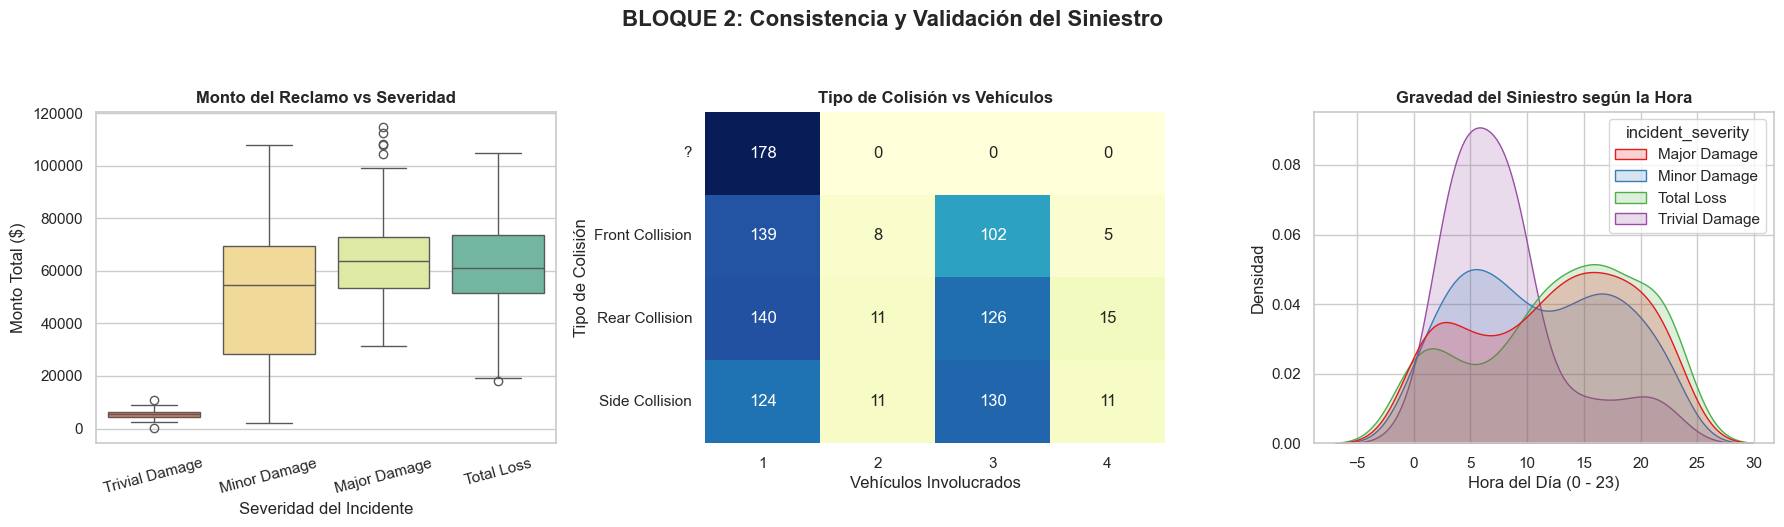

In [39]:
# ==============================================================================
# BLOQUE 2: Consistencia del Siniestro y Anomalías (Cuadrícula 1x3 - Ajustado por lógica de negocio)
# ==============================================================================
print("\nGenerando Cuadrícula del Bloque 2...")
# Nota: Como en este bloque definimos 3 gráficos principales, usamos un diseño de 1 fila x 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2.1. Severidad vs Monto Total
sns.boxplot(data=df, x='incident_severity', y='total_claim_amount', palette='Spectral', 
            order=['Trivial Damage', 'Minor Damage', 'Major Damage', 'Total Loss'], ax=axes[0])
axes[0].set_title('Monto del Reclamo vs Severidad', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Severidad del Incidente')
axes[0].set_ylabel('Monto Total ($)')
axes[0].tick_params(axis='x', rotation=15)

# 2.2. Validación de Tipo de Colisión vs Vehículos Involucrados
sns.heatmap(pd.crosstab(df['collision_type'], df['number_of_vehicles_involved']), annot=True, fmt='d', cmap='YlGnBu', cbar=False, ax=axes[1])
axes[1].set_title('Tipo de Colisión vs Vehículos', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Vehículos Involucrados')
axes[1].set_ylabel('Tipo de Colisión')

# 2.3. Densidad de la Hora según Severidad
sns.kdeplot(data=df, x='incident_hour_of_the_day', hue='incident_severity', common_norm=False, fill=True, palette='Set1', alpha=0.2, ax=axes[2])
axes[2].set_title('Gravedad del Siniestro según la Hora', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Hora del Día (0 - 23)')
axes[2].set_ylabel('Densidad')

plt.suptitle('BLOQUE 2: Consistencia y Validación del Siniestro', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()



Generando Cuadrícula del Bloque 3...


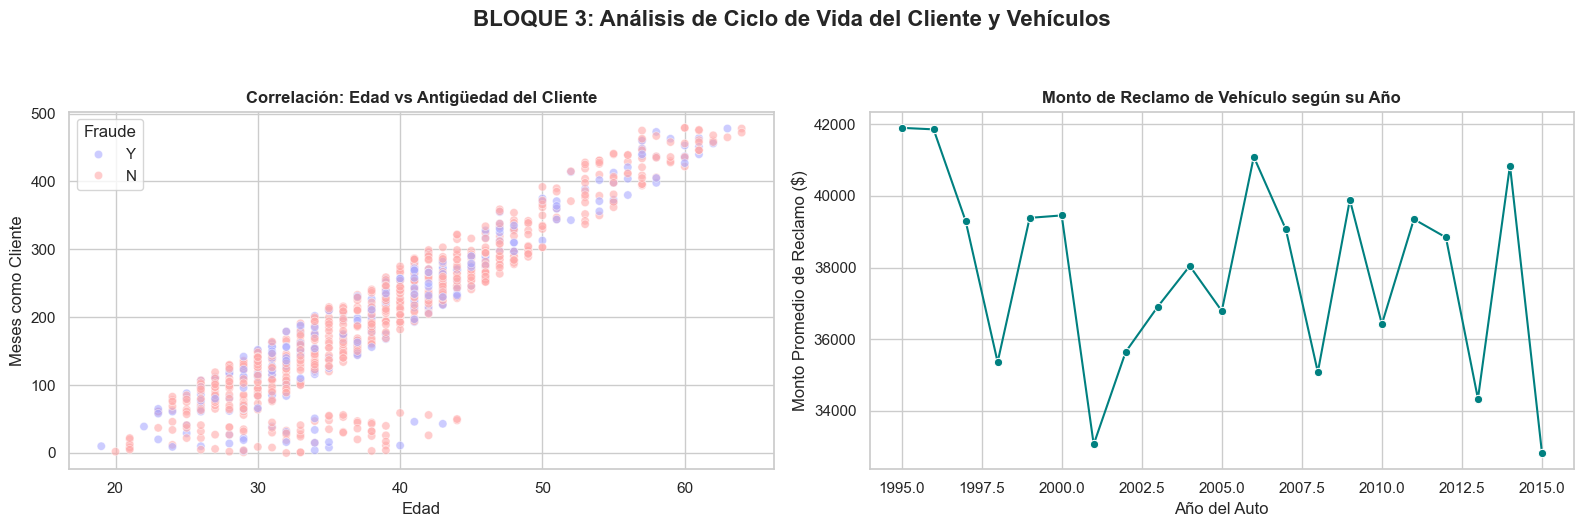

In [40]:

# ==============================================================================
# BLOQUE 3: Ciclo de Vida y Perfil de Activos (Fila 1x2)
# ==============================================================================
print("\nGenerando Cuadrícula del Bloque 3...")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 3.1. Edad vs Meses como Cliente
sns.scatterplot(data=df, x='age', y='months_as_customer', alpha=0.6, hue='fraud_reported', palette='bwr', ax=axes[0])
axes[0].set_title('Correlación: Edad vs Antigüedad del Cliente', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Meses como Cliente')
axes[0].legend(title='Fraude')

# 3.2. Tendencia del Año del Auto vs Reclamo
sns.lineplot(data=df, x='auto_year', y='vehicle_claim', marker='o', color='teal', errorbar=None, ax=axes[1])
axes[1].set_title('Monto de Reclamo de Vehículo según su Año', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Año del Auto')
axes[1].set_ylabel('Monto Promedio de Reclamo ($)')

plt.suptitle('BLOQUE 3: Análisis de Ciclo de Vida del Cliente y Vehículos', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Generando análisis avanzados y proporcionales...


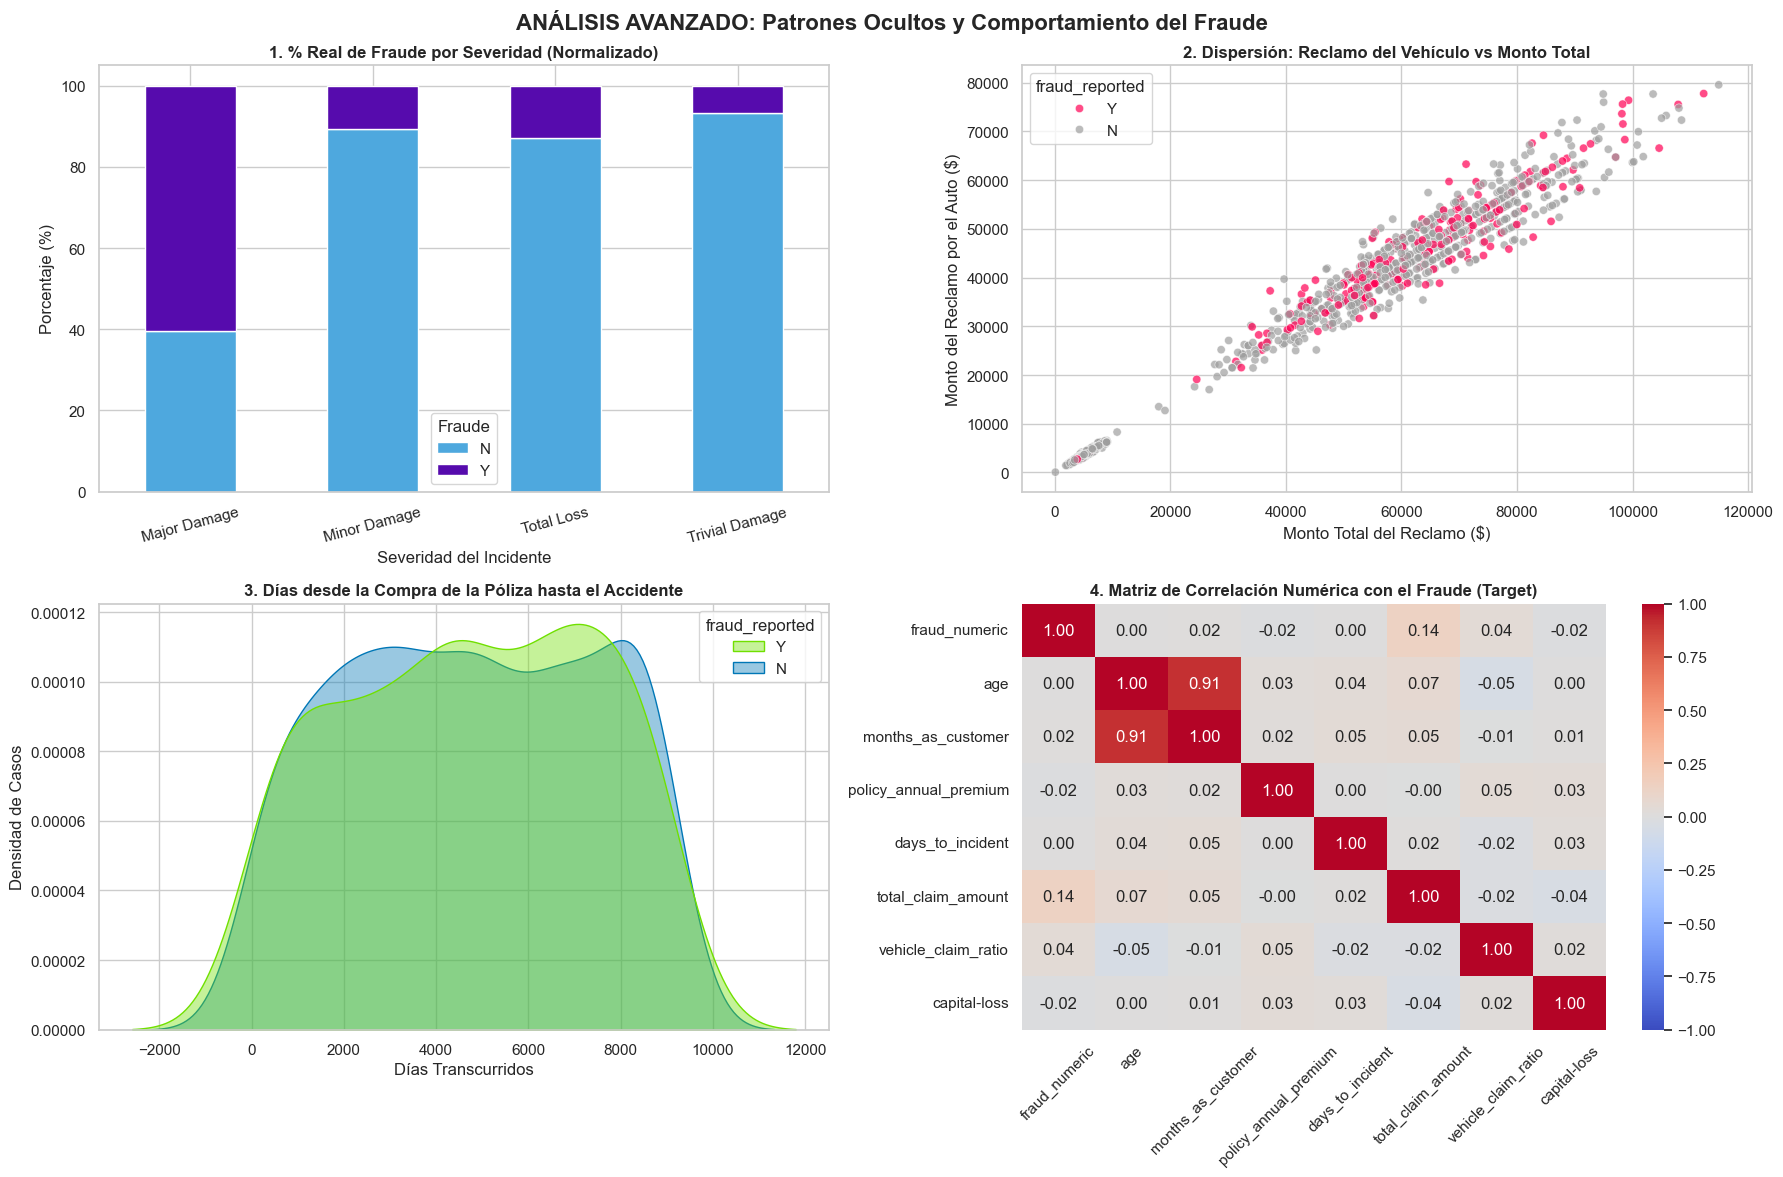

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- INGENIERÍA DE VARIABLES RÁPIDA PARA EL ANÁLISIS ---
# 1. Calculamos los días transcurridos entre la compra de la póliza y el accidente
df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'])
df['incident_date'] = pd.to_datetime(df['incident_date'])
df['days_to_incident'] = (df['incident_date'] - df['policy_bind_date']).dt.days

# 2. Creamos una tasa de reclamo (qué porcentaje del total se va a la reparación del auto)
df['vehicle_claim_ratio'] = df['vehicle_claim'] / (df['total_claim_amount'] + 1) # +1 evita división por cero

# 3. Convertimos la variable objetivo a binaria (0 y 1) para poder calcular correlaciones reales
df['fraud_numeric'] = df['fraud_reported'].map({'Y': 1, 'N': 0})


# --- CONFIGURACIÓN DE LA NUEVA CUADRÍCULA 2x2 ---
print("Generando análisis avanzados y proporcionales...")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ==============================================================================
# 1. TASA DE FRAUDE NORMALIZADA POR SEVERIDAD (100% Stacked Bar)
# ==============================================================================
# En lugar de ver "cuántos", vemos "qué porcentaje" de cada categoría es fraude
crosstab_sev = pd.crosstab(df['incident_severity'], df['fraud_reported'], normalize='index') * 100
crosstab_sev.plot(kind='bar', stacked=True, color=['#4ea8de', '#560bad'], ax=axes[0, 0])
axes[0, 0].set_title('1. % Real de Fraude por Severidad (Normalizado)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Severidad del Incidente')
axes[0, 0].set_ylabel('Porcentaje (%)')
axes[0, 0].tick_params(axis='x', rotation=15)
axes[0, 0].legend(title='Fraude')

# ==============================================================================
# 2. RELACIÓN ENTRE MONTOS: RECLAMO DE AUTO VS TOTAL
# ==============================================================================
# Buscamos anomalías. Los fraudes suelen inflar el "vehicle_claim" al máximo posible.
sns.scatterplot(data=df, x='total_claim_amount', y='vehicle_claim', hue='fraud_reported', 
                palette={'Y': '#ff0054', 'N': '#9e9e9e'}, alpha=0.7, ax=axes[0, 1])
axes[0, 1].set_title('2. Dispersión: Reclamo del Vehículo vs Monto Total', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Monto Total del Reclamo ($)')
axes[0, 1].set_ylabel('Monto del Reclamo por el Auto ($)')

# ==============================================================================
# 3. EL "RELOJ DEL FRAUDE": ANTIGÜEDAD DE LA PÓLIZA AL MOMENTO DEL SINIESTRO
# ==============================================================================
# ¿Hay un pico de fraudes en pólizas que se compraron hace muy pocos días?
sns.kdeplot(data=df, x='days_to_incident', hue='fraud_reported', common_norm=False, 
            fill=True, palette={'Y': '#70e000', 'N': '#0077b6'}, alpha=0.4, ax=axes[1, 0])
axes[1, 0].set_title('3. Días desde la Compra de la Póliza hasta el Accidente', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Días Transcurridos')
axes[1, 0].set_ylabel('Densidad de Casos')

# ==============================================================================
# 4. CORRELACIÓN MATRICIAL DE VARIABLES FINANCIERAS Y EDAD CON EL FRAUDE
# ==============================================================================
# Seleccionamos las numéricas clave y medimos su correlación lineal directa con la variable fraude (0 o 1)
num_cols = ['fraud_numeric', 'age', 'months_as_customer', 'policy_annual_premium', 
            'days_to_incident', 'total_claim_amount', 'vehicle_claim_ratio', 'capital-loss']
corr_matrix = df[num_cols].corr(method='spearman')

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, cbar=True, ax=axes[1, 1])
axes[1, 1].set_title('4. Matriz de Correlación Numérica con el Fraude (Target)', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('ANÁLISIS AVANZADO: Patrones Ocultos y Comportamiento del Fraude', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

Generando análisis de probabilidad de fraude según el perfil del asegurado...


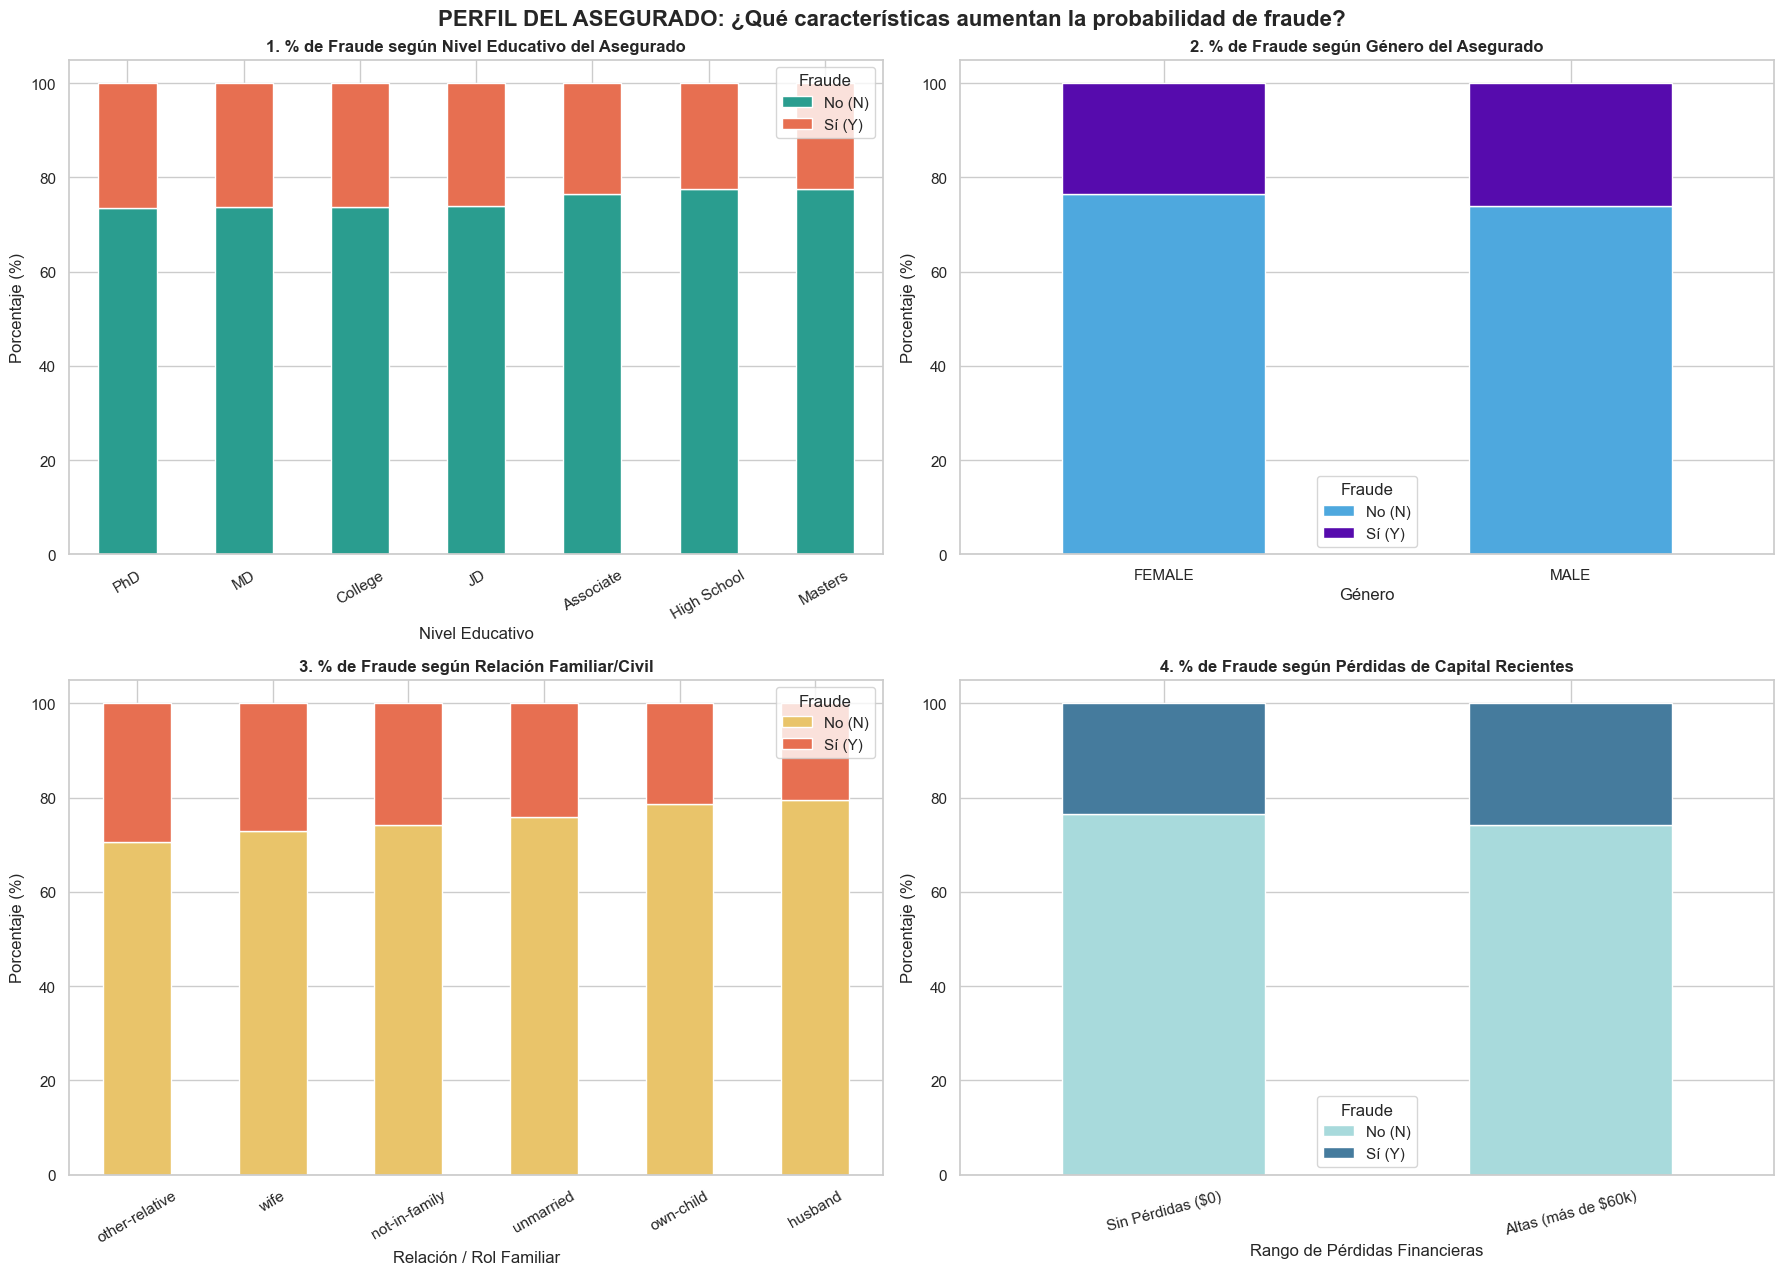

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- INGENIERÍA DE VARIABLES RÁPIDA PARA EL PERFIL FINANCIERO ---
# Para analizar 'capital-loss' como una probabilidad, creamos rangos (bins)
# ya que es una variable numérica continua.
def agrupar_perdidas(val):
    if val == 0:
        return 'Sin Pérdidas ($0)'
    elif val > 0 and val <= 30000:
        return 'Bajas (hasta $30k)'
    elif val > 30000 and val <= 60000:
        return 'Medias ($30k a $60k)'
    else:
        return 'Altas (más de $60k)'

# Aplicamos la función si la columna existe (asegurándonos de manejar el guion bajo/medio si varía)
col_loss = 'capital-loss' if 'capital-loss' in df.columns else 'capital_loss'
df['rango_perdidas_capital'] = df[col_loss].apply(agrupar_perdidas)

# --- CONFIGURACIÓN DE LA CUADRÍCULA 2x2 ---
print("Generando análisis de probabilidad de fraude según el perfil del asegurado...")
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# ==============================================================================
# 1. PORCENTAJE DE FRAUDE POR NIVEL EDUCATIVO
# ==============================================================================
crosstab_edu = pd.crosstab(df['insured_education_level'], df['fraud_reported'], normalize='index') * 100
# Ordenamos para que sea más fácil ver cuál tiene más fraude
crosstab_edu = crosstab_edu.sort_values(by='Y', ascending=False)

crosstab_edu.plot(kind='bar', stacked=True, color=['#2a9d8f', '#e76f51'], ax=axes[0, 0])
axes[0, 0].set_title('1. % de Fraude según Nivel Educativo del Asegurado', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Nivel Educativo')
axes[0, 0].set_ylabel('Porcentaje (%)')
axes[0, 0].tick_params(axis='x', rotation=30)
axes[0, 0].legend(title='Fraude', labels=['No (N)', 'Sí (Y)'])

# ==============================================================================
# 2. PORCENTAJE DE FRAUDE POR GÉNERO
# ==============================================================================
crosstab_sex = pd.crosstab(df['insured_sex'], df['fraud_reported'], normalize='index') * 100
crosstab_sex.plot(kind='bar', stacked=True, color=['#4ea8de', '#560bad'], ax=axes[0, 1])
axes[0, 1].set_title('2. % de Fraude según Género del Asegurado', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Género')
axes[0, 1].set_ylabel('Porcentaje (%)')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='Fraude', labels=['No (N)', 'Sí (Y)'])

# ==============================================================================
# 3. PORCENTAJE DE FRAUDE POR RELACIÓN FAMILIAR / ESTADO CIVIL
# ==============================================================================
crosstab_rel = pd.crosstab(df['insured_relationship'], df['fraud_reported'], normalize='index') * 100
crosstab_rel = crosstab_rel.sort_values(by='Y', ascending=False)

crosstab_rel.plot(kind='bar', stacked=True, color=['#e9c46a', '#e76f51'], ax=axes[1, 0])
axes[1, 0].set_title('3. % de Fraude según Relación Familiar/Civil', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Relación / Rol Familiar')
axes[1, 0].set_ylabel('Porcentaje (%)')
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].legend(title='Fraude', labels=['No (N)', 'Sí (Y)'])

# ==============================================================================
# 4. PORCENTAJE DE FRAUDE POR RANGOS DE PÉRDIDAS FINANCIERAS
# ==============================================================================
crosstab_loss = pd.crosstab(df['rango_perdidas_capital'], df['fraud_reported'], normalize='index') * 100
# Orden lógico de los rangos
orden_loss = ['Sin Pérdidas ($0)', 'Bajas (hasta $30k)', 'Medias ($30k a $60k)', 'Altas (más de $60k)']
# Reindexamos solo con los que existan en el resultado para evitar errores
crosstab_loss = crosstab_loss.reindex([r for r in orden_loss if r in crosstab_loss.index])

crosstab_loss.plot(kind='bar', stacked=True, color=['#a8dadc', '#457b9d'], ax=axes[1, 1])
axes[1, 1].set_title('4. % de Fraude según Pérdidas de Capital Recientes', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Rango de Pérdidas Financieras')
axes[1, 1].set_ylabel('Porcentaje (%)')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].legend(title='Fraude', labels=['No (N)', 'Sí (Y)'])

plt.suptitle('PERFIL DEL ASEGURADO: ¿Qué características aumentan la probabilidad de fraude?', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

Buscando patrones de comportamiento y estilo de vida...


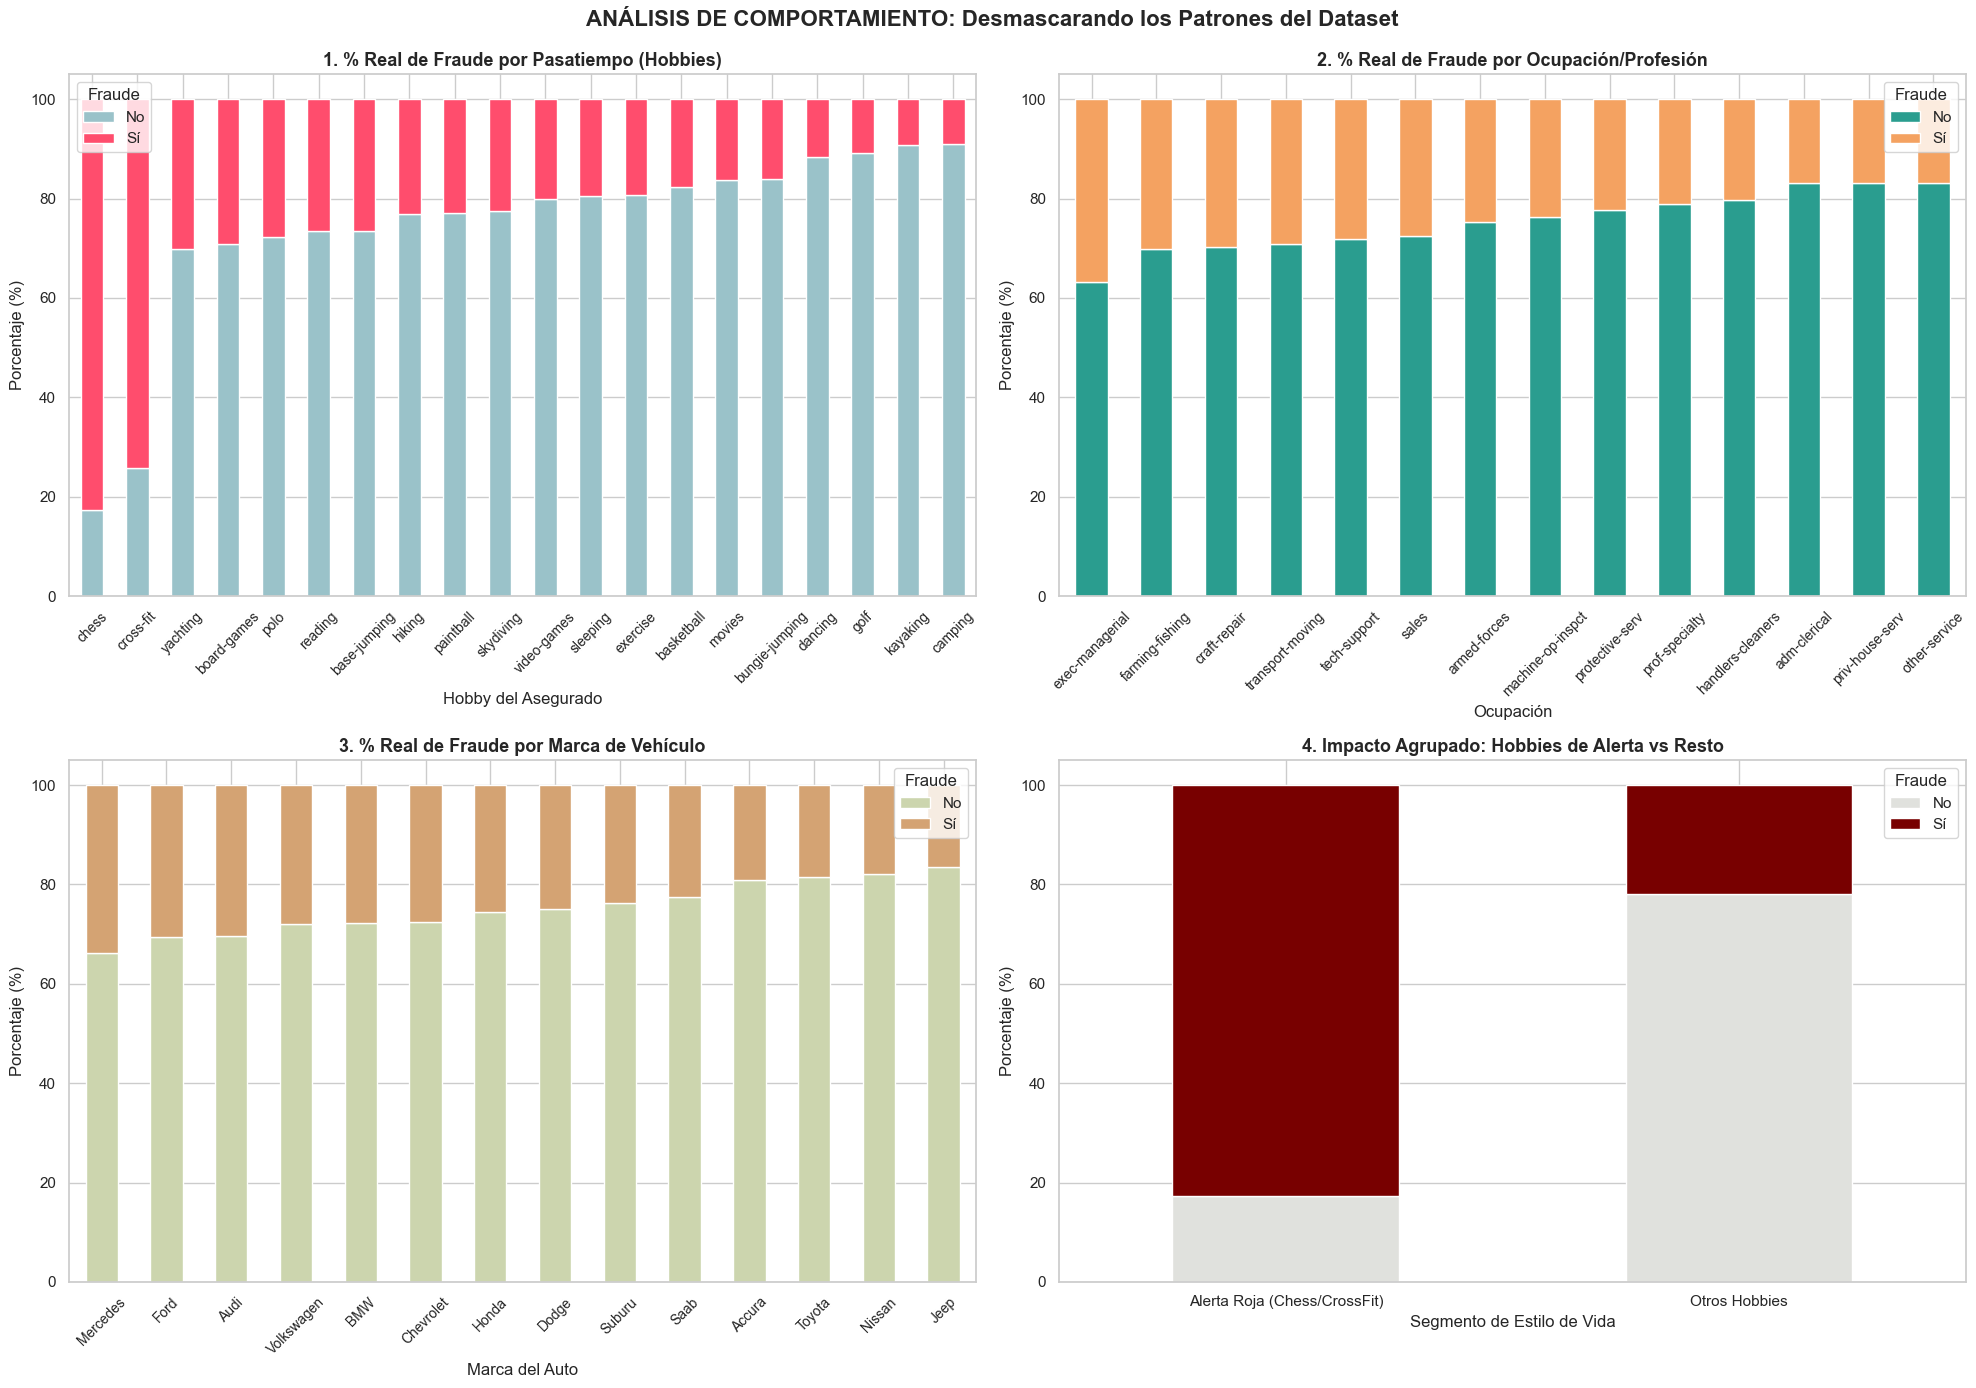

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Buscando patrones de comportamiento y estilo de vida...")
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# ==============================================================================
# 1. % DE FRAUDE POR PASATIEMPO (INSURED_HOBBIES) - ¡Aquí está el truco del dataset!
# ==============================================================================
crosstab_hobby = pd.crosstab(df['insured_hobbies'], df['fraud_reported'], normalize='index') * 100
crosstab_hobby = crosstab_hobby.sort_values(by='Y', ascending=False)

crosstab_hobby.plot(kind='bar', stacked=True, color=['#9ac2c9', '#ff4d6d'], ax=axes[0, 0])
axes[0,0].set_title('1. % Real de Fraude por Pasatiempo (Hobbies)', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Hobby del Asegurado')
axes[0,0].set_ylabel('Porcentaje (%)')
axes[0,0].tick_params(axis='x', rotation=45, labelsize=10)
axes[0,0].legend(title='Fraude', labels=['No', 'Sí'])

# ==============================================================================
# 2. % DE FRAUDE POR OCUPACIÓN (INSURED_OCCUPATION)
# ==============================================================================
crosstab_occ = pd.crosstab(df['insured_occupation'], df['fraud_reported'], normalize='index') * 100
crosstab_occ = crosstab_occ.sort_values(by='Y', ascending=False)

crosstab_occ.plot(kind='bar', stacked=True, color=['#2a9d8f', '#f4a261'], ax=axes[0, 1])
axes[0, 1].set_title('2. % Real de Fraude por Ocupación/Profesión', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Ocupación')
axes[0, 1].set_ylabel('Porcentaje (%)')
axes[0, 1].tick_params(axis='x', rotation=45, labelsize=10)
axes[0, 1].legend(title='Fraude', labels=['No', 'Sí'])

# ==============================================================================
# 3. % DE FRAUDE POR MARCA DE AUTO (AUTO_MAKE)
# ==============================================================================
crosstab_make = pd.crosstab(df['auto_make'], df['fraud_reported'], normalize='index') * 100
crosstab_make = crosstab_make.sort_values(by='Y', ascending=False)

crosstab_make.plot(kind='bar', stacked=True, color=['#ccd5ae', '#d4a373'], ax=axes[1, 0])
axes[1, 0].set_title('3. % Real de Fraude por Marca de Vehículo', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Marca del Auto')
axes[1, 0].set_ylabel('Porcentaje (%)')
axes[1, 0].tick_params(axis='x', rotation=45, labelsize=10)
axes[1, 0].legend(title='Fraude', labels=['No', 'Sí'])

# ==============================================================================
# 4. INGENIERÍA DE VARIABLES: SEGMENTACIÓN CONDUCTUAL (HOBBIES DE ALTO VS BAJO RIESGO)
# ==============================================================================
# Creamos una columna que agrupa si el hobby es de altísimo riesgo según la gráfica 1
# (Normalmente en este dataset Chess y CrossFit rompen la gráfica con >80% de fraude)
hobbies_alerta = ['chess', 'crossfit']
df['hobby_riesgo'] = df['insured_hobbies'].str.lower().apply(lambda x: 'Alerta Roja (Chess/CrossFit)' if x in hobbies_alerta else 'Otros Hobbies')

crosstab_riesgo = pd.crosstab(df['hobby_riesgo'], df['fraud_reported'], normalize='index') * 100
crosstab_riesgo.plot(kind='bar', stacked=True, color=['#e0e1dd', '#780000'], ax=axes[1, 1])
axes[1, 1].set_title('4. Impacto Agrupado: Hobbies de Alerta vs Resto', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Segmento de Estilo de Vida')
axes[1, 1].set_ylabel('Porcentaje (%)')
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].legend(title='Fraude', labels=['No', 'Sí'])

plt.suptitle('ANÁLISIS DE COMPORTAMIENTO: Desmascarando los Patrones del Dataset', fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

Generando análisis multivariados avanzados...


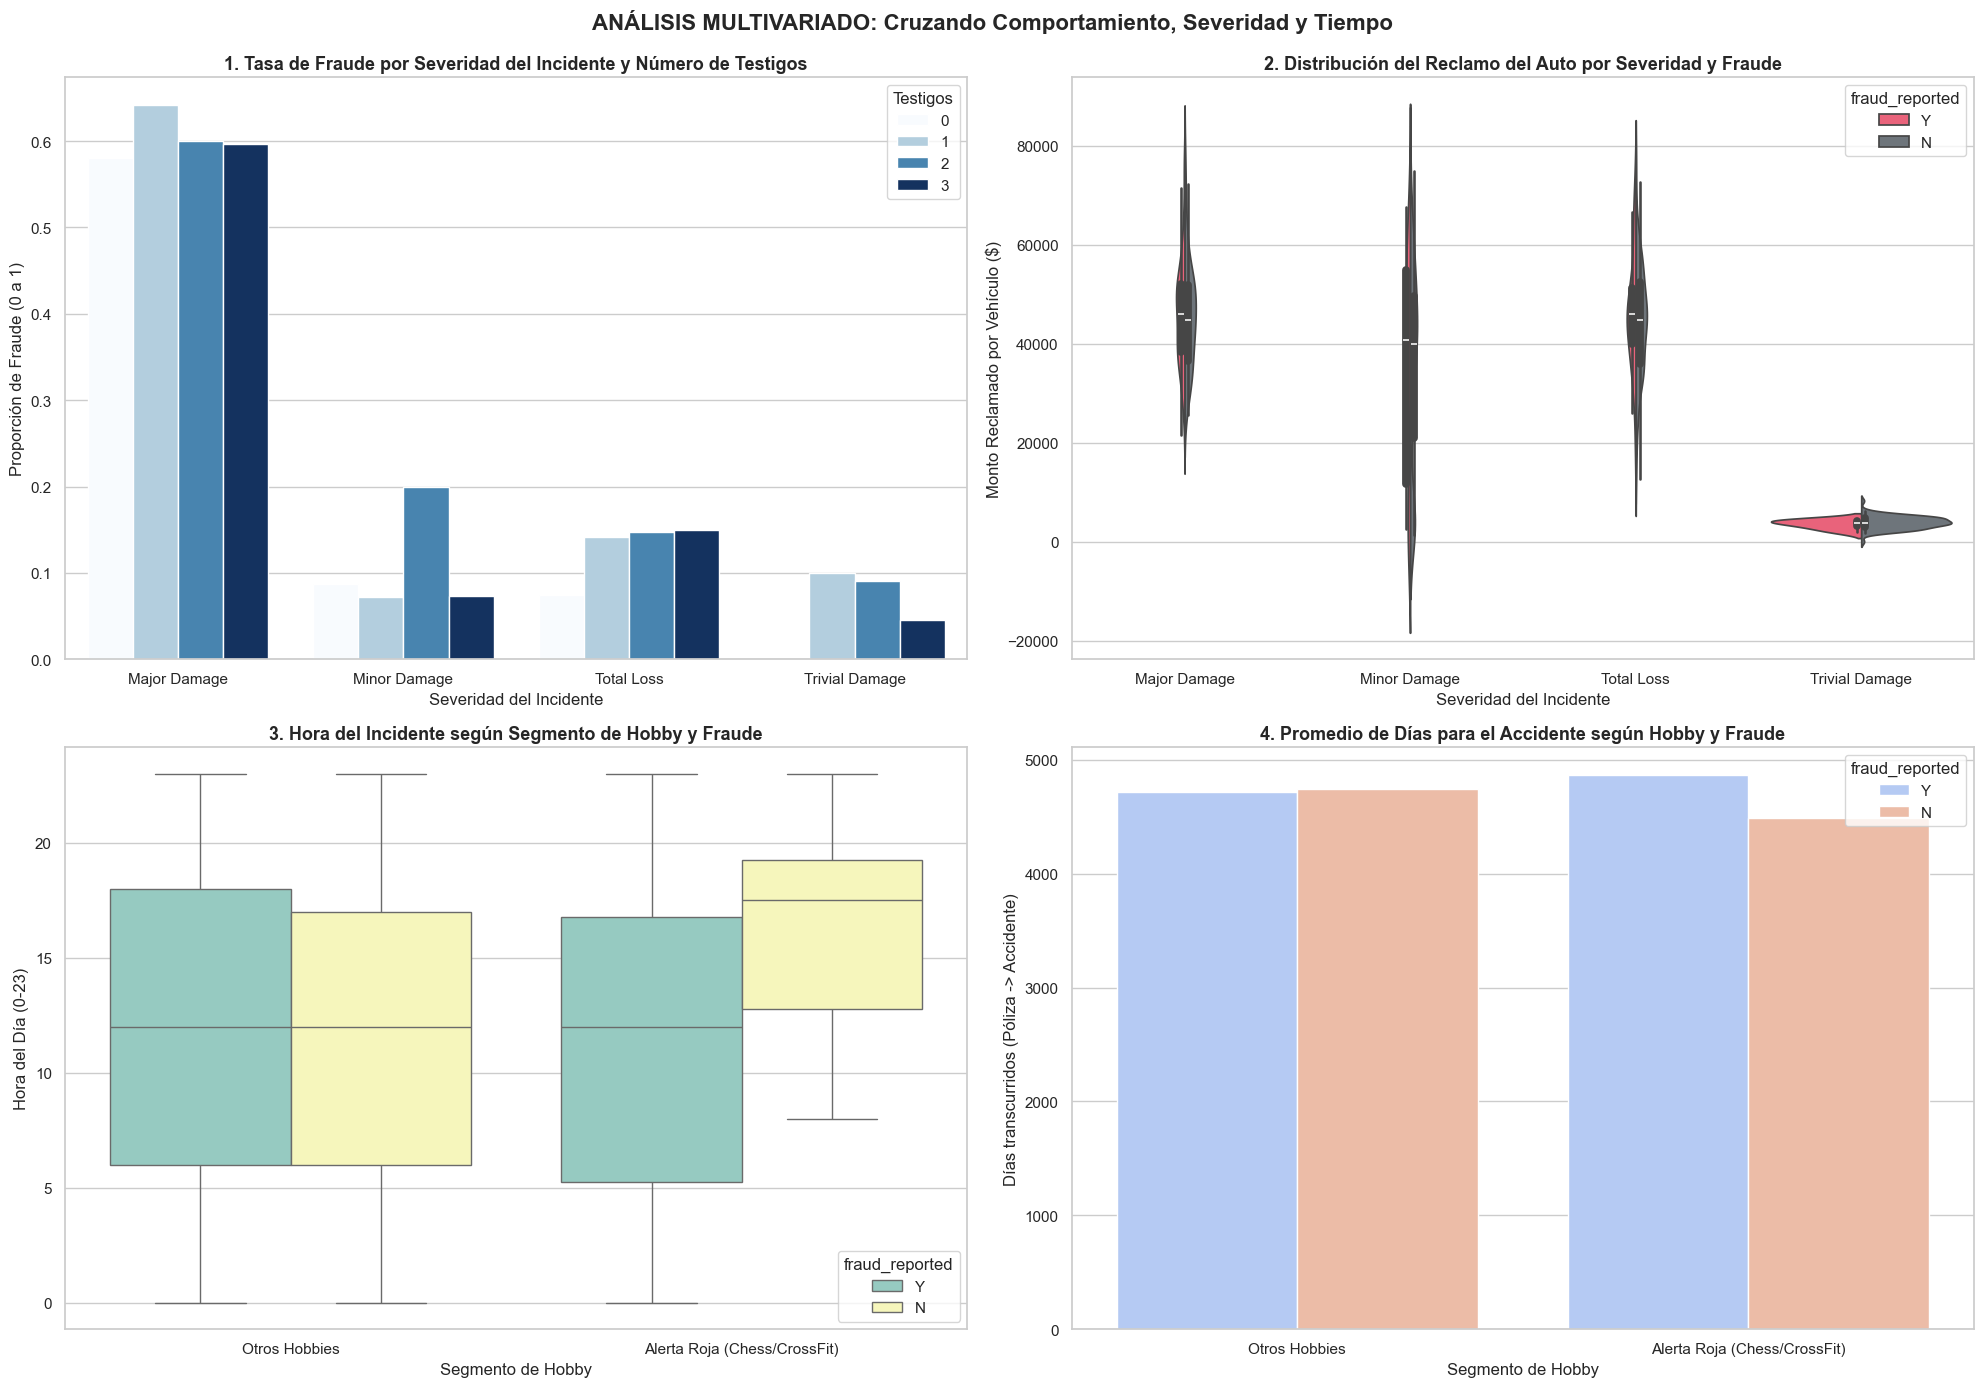

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("Generando análisis multivariados avanzados...")
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# ==============================================================================
# 1. TRIPLE CRUCE: SEVERIDAD + TESTIGOS VS FRAUDE
# ==============================================================================
# Hipótesis: Un accidente grave sin testigos es mucho más sospechoso que uno con testigos.
sns.barplot(data=df, x='incident_severity', y='fraud_numeric', hue='witnesses', 
            palette='Blues', errorbar=None, ax=axes[0, 0])
axes[0, 0].set_title('1. Tasa de Fraude por Severidad del Incidente y Número de Testigos', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Severidad del Incidente')
axes[0, 0].set_ylabel('Proporción de Fraude (0 a 1)')
axes[0, 0].legend(title='Testigos')

# ==============================================================================
# 2. EL COMPORTAMIENTO DEL MONTO: SEVERIDAD VS MONTO DE RECLAMO POR VEHÍCULO
# ==============================================================================
# Ya vimos que la severidad importa, pero ¿cómo se comportan los montos específicos en los fraudes?
sns.violinplot(data=df, x='incident_severity', y='vehicle_claim', hue='fraud_reported', 
               split=True, palette={'Y': '#ff4d6d', 'N': '#6c757d'}, ax=axes[0, 1])
axes[0, 1].set_title('2. Distribución del Reclamo del Auto por Severidad y Fraude', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Severidad del Incidente')
axes[0, 1].set_ylabel('Monto Reclamado por Vehículo ($)')

# ==============================================================================
# 3. TRIPLE CRUCE: HOBBIES DE RIESGO + HORA DEL DÍA VS FRAUDE
# ==============================================================================
# Si ya sabemos que Chess/Crossfit tienen alta tasa, ¿a qué hora ocurren sus supuestos "accidentes"?
# Nota: Asegúrate de haber corrido la celda anterior para tener la columna 'hobby_riesgo'
sns.boxplot(data=df, x='hobby_riesgo', y='incident_hour_of_the_day', hue='fraud_reported', 
            palette='Set3', ax=axes[1, 0])
axes[1, 0].set_title('3. Hora del Incidente según Segmento de Hobby y Fraude', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Segmento de Hobby')
axes[1, 0].set_ylabel('Hora del Día (0-23)')

# ==============================================================================
# 4. LA VERDADERA RELACIÓN TEMPORAL: ANTIGÜEDAD DE LA PÓLIZA EN FRAUDES
# ==============================================================================
# Evaluemos si los fraudes en los hobbies sospechosos ocurren rápido tras comprar la póliza.
# Nota: Requiere la columna 'days_to_incident' calculada en pasos anteriores
sns.barplot(data=df, x='hobby_riesgo', y='days_to_incident', hue='fraud_reported', 
            palette='coolwarm', errorbar=None, ax=axes[1, 1])
axes[1, 1].set_title('4. Promedio de Días para el Accidente según Hobby y Fraude', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Segmento de Hobby')
axes[1, 1].set_ylabel('Días transcurridos (Póliza -> Accidente)')

plt.suptitle('ANÁLISIS MULTIVARIADO: Cruzando Comportamiento, Severidad y Tiempo', fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

In [33]:
from ordinalcorr import hetcor

# 1. Creamos el DataFrame filtrado con los tipos de datos que quieres
df_filtered = df[['months_as_customer','incident_severity','total_claim_amount','incident_date','_c39','fraud_reported','insured_education_level', 'insured_hobbies', 'insured_occupation']].copy()


columnas_a_eliminar = ['_c39'] 
df_filtered = df_filtered.drop(columns=columnas_a_eliminar)

# 2. Convertir el resto de las columnas de texto ('object') a categorías
for col in df_filtered.select_dtypes(include=['object']).columns:
    df_filtered[col] = df_filtered[col].astype('category').cat.codes

# Eliminar filas con valores faltantes (si es necesario)
df_filtered = df_filtered.replace(-1, np.nan).dropna()

# 3. Ejecutar hetcor
hc_df = hetcor(df_filtered)
print(hc_df)

                         months_as_customer  incident_severity  \
months_as_customer                 1.000000          -0.063098   
incident_severity                 -0.063098           1.000000   
total_claim_amount                 0.062108          -0.391746   
incident_date                     -0.002985           0.019892   
fraud_reported                     0.027709          -0.588132   
insured_education_level           -0.008994          -0.008140   
insured_hobbies                   -0.086220          -0.018925   
insured_occupation                 0.011784          -0.007330   

                         total_claim_amount  incident_date  fraud_reported  \
months_as_customer                 0.062108      -0.002985        0.027709   
incident_severity                 -0.391746       0.019892       -0.588132   
total_claim_amount                 1.000000      -0.034415        0.241007   
incident_date                     -0.034415       1.000000       -0.065124   
fraud_reported 

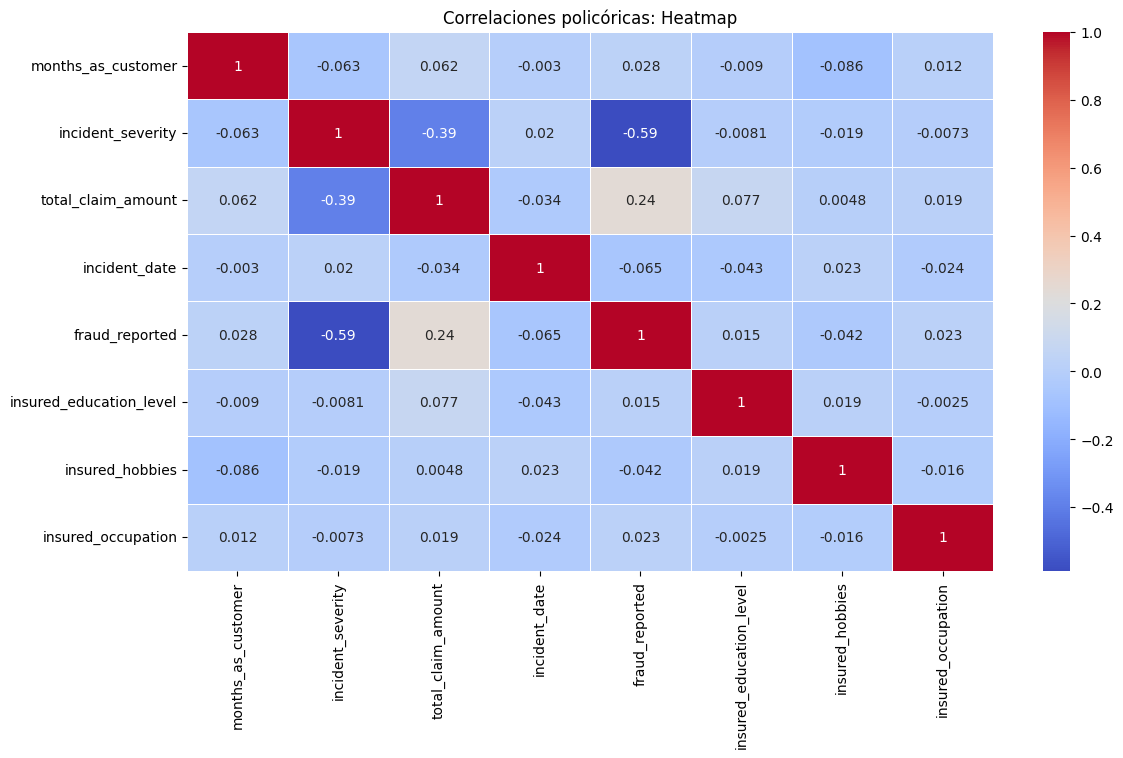

In [34]:
plt.figure(figsize=(13, 7))
sns.heatmap(hc_df, annot=True , cmap='coolwarm', linewidths=0.5)
plt.title('Correlaciones policóricas: Heatmap')
plt.show()